# 01. 전처리 (Preprocessing)

**Patch Verdict — 요루 패치 정당성 분석**

이 노트북에서 하는 것:
1. 원본 CSV 로드 및 기본 점검
2. 액트 순서·패치 경계 정의
3. 파생 피처 생성 (변화율, 상대 지표)
4. 경쟁 요원 피처 결합
5. VCT 산티아고 프로씬 피처 생성
6. 최종 분석용 데이터셋 저장

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. 원본 데이터 로드

In [3]:
# 경로 설정 — 실제 파일 위치에 맞게 수정
DATA_DIR = "./"

act       = pd.read_csv(DATA_DIR + "yoru_act_history_20260329_2146.csv")
act_tier  = pd.read_csv(DATA_DIR + "yoru_act_history_20260329_1809.csv")
map_act   = pd.read_csv(DATA_DIR + "yoru_map_act_history_20260329_2148.csv")
map_tier  = pd.read_csv(DATA_DIR + "yoru_map_act_history_20260329_1810.csv")
rival     = pd.read_csv(DATA_DIR + "rival_map_act_history_20260329_2157.csv")
vct       = pd.read_csv(DATA_DIR + "vct_santiago_2026_clean.csv")
patches   = pd.read_csv(DATA_DIR + "yoru_patch_notes.csv")

print("act      :", act.shape)
print("act_tier :", act_tier.shape)
print("map_act  :", map_act.shape)
print("map_tier :", map_tier.shape)
print("rival    :", rival.shape)
print("vct      :", vct.shape)
print("patches  :", patches.shape)

act      : (18, 17)
act_tier : (72, 9)
map_act  : (104, 10)
map_tier : (416, 10)
rival    : (312, 10)
vct      : (590, 8)
patches  : (6, 10)


## 2. 액트 순서 및 패치 경계 정의

In [4]:
# 전체 액트 순서 (시계열 인덱스용)
ACT_ORDER = [
    "E6A3","E7A1","E7A2","E7A3",
    "E8A1","E8A2","E8A3",
    "E9A1","E9A2","E9A3",
    "E10A1","E10A2","E10A3",
    "E11A1","E11A2","E11A3",
    "E12A1","V26A2"
]

# 패치 경계 정의
# rework : E10A1 (패치 5.01) — 리워크 적용 첫 액트
# nerf   : V26A2 (패치 12.05) — 너프 적용 첫 액트
PATCH_EVENTS = {
    "E10A1": {"type": "rework", "patch": "5.01"},
    "V26A2": {"type": "nerf",   "patch": "12.05"},
}

# 분석 구간 레이블
# pre_rework  : E6A3 ~ E9A3  (리워크 이전)
# post_rework : E10A1 ~ E12A1 (리워크 이후, 너프 이전)
# post_nerf   : V26A2~        (너프 이후)
def get_era(act_name):
    idx = ACT_ORDER.index(act_name)
    rework_idx = ACT_ORDER.index("E10A1")
    nerf_idx   = ACT_ORDER.index("V26A2")
    if idx < rework_idx:
        return "pre_rework"
    elif idx < nerf_idx:
        return "post_rework"
    else:
        return "post_nerf"

act["act_idx"] = act["act"].map({a: i for i, a in enumerate(ACT_ORDER)})
act["era"]     = act["act"].map(get_era)

print(act[["act","act_idx","era","win_rate","pick_rate_pct"]].to_string(index=False))

  act  act_idx         era  win_rate  pick_rate_pct
 E6A3        0  pre_rework    48.210          0.960
 E7A1        1  pre_rework    48.390          1.010
 E7A2        2  pre_rework    48.480          1.470
 E7A3        3  pre_rework    48.930          1.170
 E8A1        4  pre_rework    48.410          1.390
 E8A2        5  pre_rework    48.620          1.320
 E8A3        6  pre_rework    48.300          1.250
 E9A1        7  pre_rework    48.530          1.200
 E9A2        8  pre_rework    48.470          1.340
 E9A3        9  pre_rework    49.010          1.420
E10A1       10 post_rework    49.370          2.150
E10A2       11 post_rework    49.080          2.420
E10A3       12 post_rework    48.880          2.370
E11A1       13 post_rework    48.650          2.640
E11A2       14 post_rework    48.990          3.520
E11A3       15 post_rework    48.810          2.680
E12A1       16 post_rework    49.010          4.520
V26A2       17   post_nerf    48.210          0.710


## 3. 요루 액트별 파생 피처 생성

In [5]:
act = act.sort_values("act_idx").reset_index(drop=True)

# 전 액트 대비 변화량
act["wr_delta"]   = act["win_rate"].diff()           # 승률 변화
act["pr_delta"]   = act["pick_rate_pct"].diff()      # 픽률 변화
act["pr_pct_chg"] = act["pick_rate_pct"].pct_change() * 100  # 픽률 변화율(%)

# 구간별 평균 대비 편차
era_means = act.groupby("era")[["win_rate","pick_rate_pct"]].mean()
print("[구간별 평균]")
print(era_means)

# 전체 평균 대비 상대 승률 (50% 기준 편차)
act["wr_vs_50"]  = act["win_rate"] - 50.0

# 롤링 평균 (3액트 이동평균 — 단기 노이즈 제거)
act["wr_roll3"]  = act["win_rate"].rolling(3, min_periods=1).mean()
act["pr_roll3"]  = act["pick_rate_pct"].rolling(3, min_periods=1).mean()

# V26A2 샘플 수 경고 플래그 (18,940판 — 액트 초반 스냅샷)
MATCH_THRESHOLD = 50000
act["low_sample"] = act["matches"] < MATCH_THRESHOLD

print("\n[요루 액트별 피처]")
print(act[["act","era","win_rate","pick_rate_pct","wr_delta","pr_delta","pr_pct_chg","low_sample"]].to_string(index=False))

[구간별 평균]
             win_rate  pick_rate_pct
era                                 
post_nerf      48.210          0.710
post_rework    48.970          2.900
pre_rework     48.535          1.253

[요루 액트별 피처]
  act         era  win_rate  pick_rate_pct  wr_delta  pr_delta  pr_pct_chg  low_sample
 E6A3  pre_rework    48.210          0.960       NaN       NaN         NaN       False
 E7A1  pre_rework    48.390          1.010     0.180     0.050       5.208       False
 E7A2  pre_rework    48.480          1.470     0.090     0.460      45.545       False
 E7A3  pre_rework    48.930          1.170     0.450    -0.300     -20.408       False
 E8A1  pre_rework    48.410          1.390    -0.520     0.220      18.803       False
 E8A2  pre_rework    48.620          1.320     0.210    -0.070      -5.036       False
 E8A3  pre_rework    48.300          1.250    -0.320    -0.070      -5.303       False
 E9A1  pre_rework    48.530          1.200     0.230    -0.050      -4.000       False
 E9A2  pre

## 4. 티어별 분리 피처

In [6]:
# act_tier: 각 액트 × 4티어 행 → 피벗으로 액트별 티어간 승률 분산 계산
act_tier["act_idx"] = act_tier["act"].map({a: i for i, a in enumerate(ACT_ORDER)})
act_tier = act_tier[act_tier["note"] == "ok"].copy()

# 티어별 승률 피벗
tier_pivot = act_tier.pivot_table(
    index="act", columns="tier", values="win_rate", aggfunc="first"
).reset_index()

# 티어 간 승률 분산 — 높을수록 특정 티어에 편향
tier_cols = [c for c in ["Diamond","Immortal","Immortal+","Radiant"] if c in tier_pivot.columns]
tier_pivot["wr_tier_std"] = tier_pivot[tier_cols].std(axis=1)
tier_pivot["wr_radiant_gap"] = tier_pivot.get("Radiant", np.nan) - tier_pivot.get("Diamond", np.nan)

print("[티어별 승률 + 분산]")
print(tier_pivot[["act"] + tier_cols + ["wr_tier_std","wr_radiant_gap"]].to_string(index=False))

[티어별 승률 + 분산]
  act  Diamond  Immortal  Immortal+  Radiant  wr_tier_std  wr_radiant_gap
E10A1   48.680    49.200     48.810   51.150        1.148           2.470
E10A2   48.790    48.840     50.480   49.290        0.786           0.500
E10A3   48.450    48.750     49.570   49.780        0.638           1.330
E11A1   48.320    48.510     49.010   49.190        0.410           0.870
E11A2   48.540    49.020     48.810   49.900        0.589           1.360
E11A3   48.350    48.920     49.360   49.130        0.432           0.780
E12A1   48.670    49.300     49.100   49.210        0.279           0.540
 E6A3   47.810    48.410     49.530   49.690        0.902           1.880
 E7A1   47.460    48.620     48.060   50.010        1.090           2.550
 E7A2   48.260    48.470     49.290   49.760        0.702           1.500
 E7A3   48.620    48.960     49.310   50.780        0.951           2.160
 E8A1   48.110    48.630     49.030   50.580        1.064           2.470
 E8A2   48.030    48.940

## 5. 경쟁 요원 피처 (반사이익 지표)

In [7]:
# ALL 맵, ok 데이터만
rival_all = rival[(rival["map"] == "ALL") & (rival["note"] == "ok")].copy()
rival_all["act_idx"] = rival_all["act"].map({a: i for i, a in enumerate(ACT_ORDER)})

# 에이전트별 픽률 피벗 → 액트별 한 행으로
rival_pivot = rival_all.pivot_table(
    index="act", columns="agent",
    values=["win_rate","pick_rate_pct"],
    aggfunc="first"
).reset_index()

# 컬럼 평탄화
rival_pivot.columns = [
    "_".join(c).strip("_") if c[1] else c[0]
    for c in rival_pivot.columns
]
rival_pivot = rival_pivot.rename(columns={"act_": "act"})

# 전 액트 대비 픽률 변화 (반사이익 지표)
rival_pivot = rival_pivot.sort_values("act").reset_index(drop=True)
for agent in ["KAYO", "Skye"]:
    col = f"pick_rate_pct_{agent}"
    if col in rival_pivot.columns:
        rival_pivot[f"pr_delta_{agent}"] = rival_pivot[col].diff()

print("[경쟁 요원 피처]")
print(rival_pivot.to_string(index=False))

[경쟁 요원 피처]
  act  pick_rate_pct_KAYO  pick_rate_pct_Skye  win_rate_KAYO  win_rate_Skye  pr_delta_KAYO  pr_delta_Skye
E10A1               0.740               2.760         45.300         49.780            NaN            NaN
E10A2               1.240               1.550         45.710         49.650          0.500         -1.210
E10A3               1.360               1.670         45.900         49.830          0.120          0.120
E11A1               0.990               1.860         45.920         49.650         -0.370          0.190
E11A2               1.060               1.790         45.580         49.680          0.070         -0.070
E11A3               1.090               3.120         45.910         50.150          0.030          1.330
E12A1               0.910               3.200         46.030         50.090         -0.180          0.080
V26A2               0.750               4.220         46.250         50.110         -0.160          1.020


## 6. VCT 산티아고 프로씬 피처

In [8]:
# 전체 맵 수 (픽률 분모)
total_maps = vct[["match_id","map"]].drop_duplicates().shape[0]
print(f"총 맵 수: {total_maps}")

# 에이전트별 픽 집계
agent_picks = (
    vct.assign(agent_single=vct["agent"].str.split("/"))
       .explode("agent_single")
       .groupby("agent_single")
       .agg(
           picks=("agent_single","count"),
           wins=("result", lambda x: (x=="win").sum())
       )
       .reset_index()
)
agent_picks["pick_rate_pct"] = (agent_picks["picks"] / total_maps * 100).round(1)
agent_picks["win_rate"]      = (agent_picks["wins"]  / agent_picks["picks"] * 100).round(1)
agent_picks = agent_picks.sort_values("picks", ascending=False)

print("\n[VCT 산티아고 에이전트 픽률·승률 (상위 15)]")
print(agent_picks.head(15).to_string(index=False))

# 요루 프로씬 요약
yoru_vct = vct[vct["agent"].str.contains("Yoru", na=False)].copy()
print(f"\n[요루] 총 {len(yoru_vct)}픽 / {len(yoru_vct[yoru_vct['result']=='win'])}승")
print(f"픽률: {len(yoru_vct)/total_maps*100:.1f}%  승률: {len(yoru_vct[yoru_vct['result']=='win'])/len(yoru_vct)*100:.1f}%")

# 팀별 요루 픽 현황
print("\n[팀별 요루 픽]")
print(
    yoru_vct.groupby(["team","player"])
            .agg(picks=("agent","count"), wins=("result",lambda x:(x=="win").sum()))
            .reset_index()
            .sort_values("picks",ascending=False)
            .to_string(index=False)
)

# 맵별 요루 픽
print("\n[맵별 요루 픽]")
print(
    yoru_vct.groupby("map")
            .agg(picks=("agent","count"), wins=("result",lambda x:(x=="win").sum()))
            .reset_index()
            .sort_values("picks",ascending=False)
            .to_string(index=False)
)

총 맵 수: 59

[VCT 산티아고 에이전트 픽률·승률 (상위 15)]
agent_single  picks  wins  pick_rate_pct  win_rate
       Viper     73    36        123.700    49.300
        Yoru     73    39        123.700    53.400
        Omen     66    35        111.900    53.000
        Sova     59    28        100.000    47.500
        Neon     53    27         89.800    50.900
        Fade     45    28         76.300    62.200
       Astra     45    20         76.300    44.400
      Waylay     43    21         72.900    48.800
        Raze     16     8         27.100    50.000
        Skye     15     3         25.400    20.000
     Killjoy     15     8         25.400    53.300
      Cypher     15     9         25.400    60.000
        Vyse     13     5         22.000    38.500
     Chamber     11     6         18.600    54.500
     Phoenix      9     5         15.300    55.600

[요루] 총 73픽 / 39승
픽률: 123.7%  승률: 53.4%

[팀별 요루 픽]
             team      player  picks  wins
        Paper Rex   something     14     7
Nongsh

## 7. 패치 경계 기준 변화율 계산 (핵심 피처)

In [9]:
# 패치 직전 N액트 평균 vs 직후 N액트 평균
# N=3 — 단기 반응 / N=전구간 — 전체 트렌드

def patch_impact(df, patch_act, n=3, col="pick_rate_pct"):
    """
    patch_act 기준으로 이전 n액트 평균 vs 이후 n액트 평균 비교
    반환: {before_mean, after_mean, delta, pct_change}
    """
    idx = df[df["act"] == patch_act].index[0]
    before = df.loc[max(0, idx-n):idx-1, col].mean()
    after  = df.loc[idx:idx+n-1, col].mean()
    delta  = after - before
    pct_chg = delta / before * 100 if before else None
    return {"before_mean": round(before,3), "after_mean": round(after,3),
            "delta": round(delta,3), "pct_change": round(pct_chg,2) if pct_chg else None}

act_sorted = act.sort_values("act_idx").reset_index(drop=True)

print("=" * 55)
print("[패치 5.01 리워크 — E10A1] 픽률 변화")
print(patch_impact(act_sorted, "E10A1", n=3, col="pick_rate_pct"))
print(patch_impact(act_sorted, "E10A1", n=3, col="win_rate"))

print()
print("[패치 12.05 너프 — V26A2] 픽률 변화")
# V26A2는 샘플 부족 주의
print(patch_impact(act_sorted, "V26A2", n=1, col="pick_rate_pct"))
print(patch_impact(act_sorted, "V26A2", n=1, col="win_rate"))
print("⚠  V26A2 매치 수:", act_sorted[act_sorted["act"]=="V26A2"]["matches"].values[0], "— 초반 스냅샷, 해석 주의")
print("=" * 55)

[패치 5.01 리워크 — E10A1] 픽률 변화
{'before_mean': np.float64(1.32), 'after_mean': np.float64(2.313), 'delta': np.float64(0.993), 'pct_change': np.float64(75.25)}
{'before_mean': np.float64(48.67), 'after_mean': np.float64(49.11), 'delta': np.float64(0.44), 'pct_change': np.float64(0.9)}

[패치 12.05 너프 — V26A2] 픽률 변화
{'before_mean': np.float64(4.52), 'after_mean': np.float64(0.71), 'delta': np.float64(-3.81), 'pct_change': np.float64(-84.29)}
{'before_mean': np.float64(49.01), 'after_mean': np.float64(48.21), 'delta': np.float64(-0.8), 'pct_change': np.float64(-1.63)}
⚠  V26A2 매치 수: 18940 — 초반 스냅샷, 해석 주의


## 8. 최종 데이터셋 병합 및 저장

In [10]:
# 요루 액트별 + 티어 분산 + 경쟁 요원 픽률 결합
df_main = act_sorted.merge(tier_pivot[["act","wr_tier_std","wr_radiant_gap"]], on="act", how="left")
df_main = df_main.merge(rival_pivot, on="act", how="left")

# 패치 이벤트 컬럼 추가
df_main["patch_event"] = df_main["act"].map(
    {k: v["type"] for k, v in PATCH_EVENTS.items()}
).fillna("none")
df_main["patch_version"] = df_main["act"].map(
    {k: v["patch"] for k, v in PATCH_EVENTS.items()}
)

print(f"최종 데이터셋: {df_main.shape}")
print(df_main[["act","era","win_rate","pick_rate_pct","wr_tier_std","patch_event"]].to_string(index=False))

# 저장
df_main.to_csv("yoru_processed.csv", index=False, encoding="utf-8-sig")
print("\n저장 완료: yoru_processed.csv")

최종 데이터셋: (18, 36)
  act         era  win_rate  pick_rate_pct  wr_tier_std patch_event
 E6A3  pre_rework    48.210          0.960        0.902        none
 E7A1  pre_rework    48.390          1.010        1.090        none
 E7A2  pre_rework    48.480          1.470        0.702        none
 E7A3  pre_rework    48.930          1.170        0.951        none
 E8A1  pre_rework    48.410          1.390        1.064        none
 E8A2  pre_rework    48.620          1.320        1.517        none
 E8A3  pre_rework    48.300          1.250        1.281        none
 E9A1  pre_rework    48.530          1.200        1.096        none
 E9A2  pre_rework    48.470          1.340        0.794        none
 E9A3  pre_rework    49.010          1.420        0.439        none
E10A1 post_rework    49.370          2.150        1.148      rework
E10A2 post_rework    49.080          2.420        0.786        none
E10A3 post_rework    48.880          2.370        0.638        none
E11A1 post_rework    48.650   

## 9. 빠른 시각화 — 전체 흐름 확인

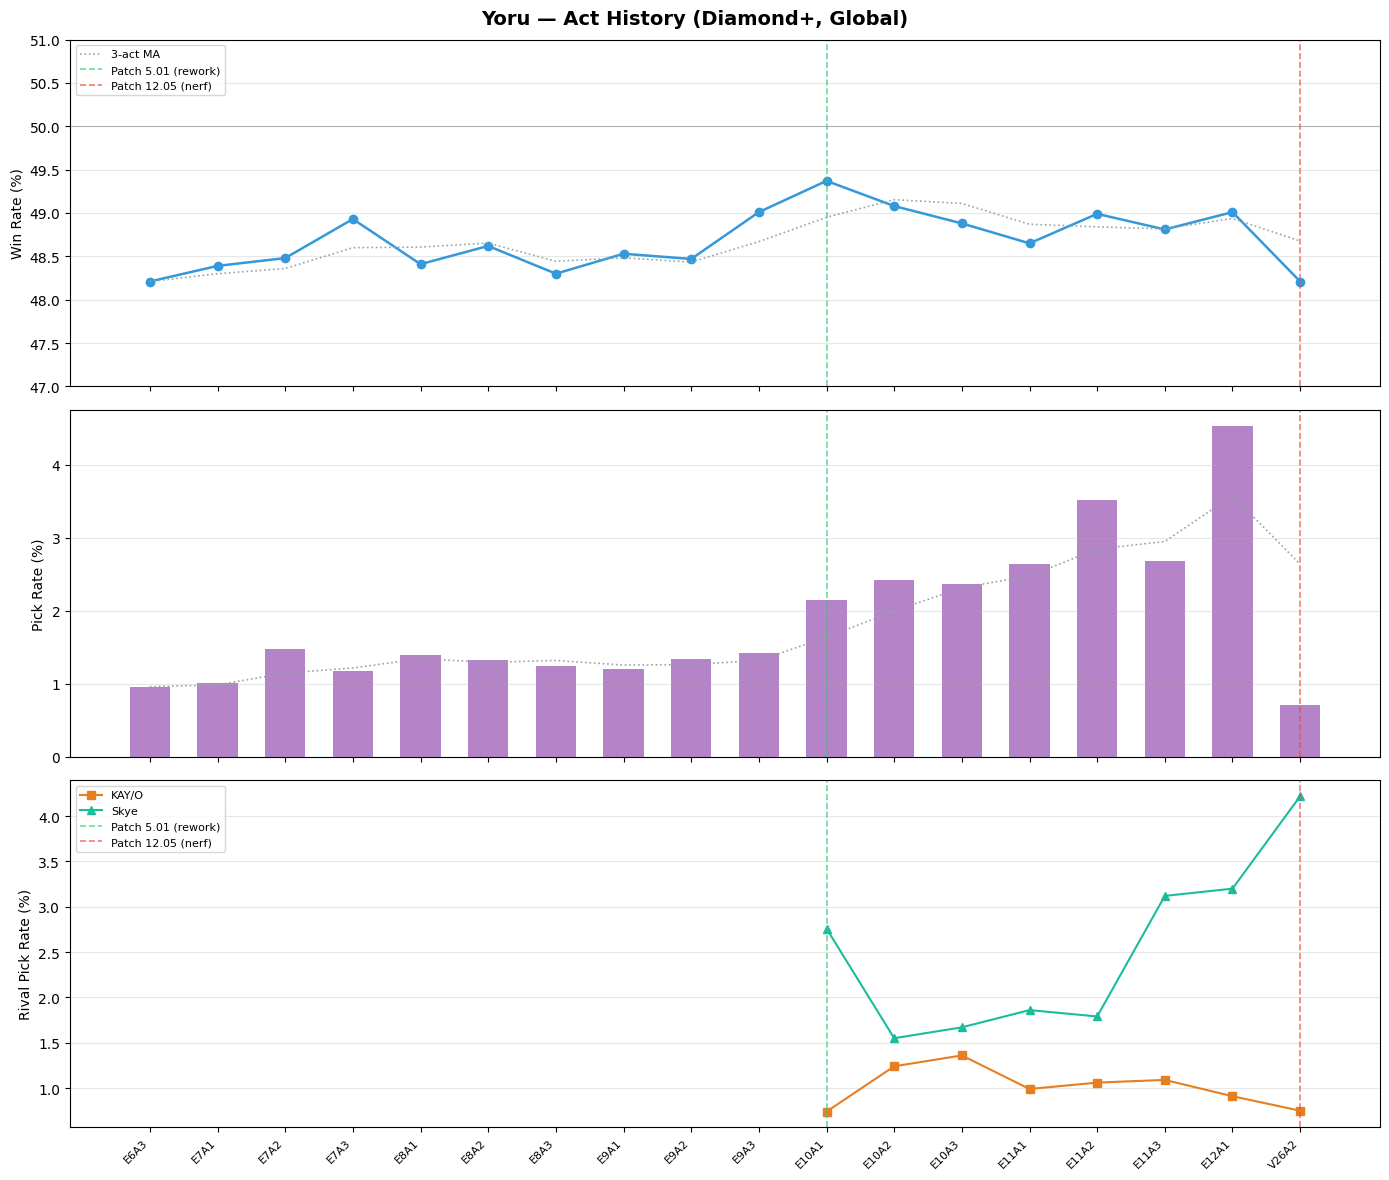

저장: yoru_act_overview.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Yoru — Act History (Diamond+, Global)", fontsize=14, fontweight="bold")

x     = df_main["act_idx"]
xlabs = df_main["act"]

# 패치 경계선 공통 함수
def draw_patch_lines(ax):
    for act_name, meta in PATCH_EVENTS.items():
        xi = ACT_ORDER.index(act_name)
        color = "#e74c3c" if meta["type"] == "nerf" else "#2ecc71"
        ax.axvline(xi, color=color, linestyle="--", linewidth=1.2, alpha=0.7,
                   label=f"Patch {meta['patch']} ({meta['type']})")

# 승률
axes[0].plot(x, df_main["win_rate"], marker="o", color="#3498db", linewidth=1.8)
axes[0].plot(x, df_main["wr_roll3"], linestyle=":", color="#95a5a6", linewidth=1.2, label="3-act MA")
axes[0].axhline(50, color="gray", linestyle="-", linewidth=0.8, alpha=0.5)
axes[0].set_ylabel("Win Rate (%)")
axes[0].set_ylim(47, 51)
draw_patch_lines(axes[0])
axes[0].legend(fontsize=8)

# 픽률
axes[1].bar(x, df_main["pick_rate_pct"], color="#9b59b6", alpha=0.75, width=0.6)
axes[1].plot(x, df_main["pr_roll3"], linestyle=":", color="#95a5a6", linewidth=1.2)
axes[1].set_ylabel("Pick Rate (%)")
draw_patch_lines(axes[1])

# 경쟁 요원 픽률
if "pick_rate_pct_KAYO" in df_main.columns:
    # rival 데이터는 E10A1부터 있으므로 NaN 구간 자동 처리
    axes[2].plot(x, df_main["pick_rate_pct_KAYO"], marker="s", color="#e67e22",
                 linewidth=1.5, label="KAY/O")
if "pick_rate_pct_Skye" in df_main.columns:
    axes[2].plot(x, df_main["pick_rate_pct_Skye"], marker="^", color="#1abc9c",
                 linewidth=1.5, label="Skye")
axes[2].set_ylabel("Rival Pick Rate (%)")
draw_patch_lines(axes[2])
axes[2].legend(fontsize=8)

# x축 레이블
for ax in axes:
    ax.set_xticks(range(len(ACT_ORDER)))
    ax.set_xticklabels(ACT_ORDER, rotation=45, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("yoru_act_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: yoru_act_overview.png")